In [1]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import netket as nk
import netket.experimental as nkx

import optax
from typing import Callable
from functools import partial
from jax.flatten_util import ravel_pytree
from pyscf import gto, scf, fci
import time
from NES_VMC_H2_631G import get_ccsd_excitations_and_sampler_edges_from_hf
from NES_VMC import NESTotalAnsatz,NESTotalAnsatz_stable,create_machine,\
        SingleStateAnsatz,create_single_machine,create_machine_stable,\
            create_machine_matrix_stable,create_machine_max_stable,\
        create_machine_matrix,NES_loss_energy,nes_vmc_gradient,nes_vmc_gradient_stable,\
        compute_qgt,sampler_info,NESFermionHopRule,\
        create_machine_stable,create_machine_matrix_stable
        
import logging
# ========== 你原有全局参数（直接复用） ==========
from pyscf import gto, scf, fci
bond_length = 1.4
geometry = [('H', (0., 0., 0.)), ('H', (bond_length, 0., 0.))]
mol = gto.M(atom=geometry, basis='STO-3G', verbose=0)
mf = scf.RHF(mol).run(verbose=0)

# FCI 精确基准
cisolver = fci.FCI(mf)
cisolver.nroots = 4
E_fcis, fcivec = cisolver.kernel()
print("="*60)
print("H₂ FCI 基准能量")
print("="*60)
for i, e in enumerate(E_fcis):
    exc = (e - E_fcis[0]) * 27.2114
    print(f"E{i} = {e:.8f} Ha  |  激发能：{exc:.4f} eV")
# ===================== NetKet 哈密顿量和采样器 =====================
ha = nkx.operator.from_pyscf_molecule(mol)

hi = nkx.hilbert.SpinOrbitalFermions(
    n_orbitals=2,
    s=1/2,
    n_fermions_per_spin=(1,1),
)

K = 3  # NES 扩展副本数
hi_ext = hi ** K  # 扩展希尔伯特空间
ha = nkx.operator.from_pyscf_molecule(mol)
Hatree_Fock = hi.all_states()[0]
single_edges, singles, doubles = get_ccsd_excitations_and_sampler_edges_from_hf(
    Hatree_Fock
)
print(f'single_edges: {single_edges}')
g = nk.graph.Graph(edges=single_edges)
single_rule = nk.sampler.rules.FermionHopRule(hilbert=hi, graph=g)
tensor_rule = nk.sampler.rules.TensorRule(hi_ext, [single_rule] * K)
#sampler = nk.sampler.MetropolisSampler(hi, rule=single_rule, n_chains=100, sweep_size=32)

SINGLE_SIZE = hi.size
ext_edges = []
for k in range(K):
    offset = k * SINGLE_SIZE
    for (i, j) in single_edges:
        ext_edges.append((i + offset, j + offset))
ext_edges = jnp.array(ext_edges)  # 转为jax数组（关键修复）
ext_edges

nes_rule = NESFermionHopRule(edges=ext_edges, K=K, single_size=SINGLE_SIZE)

jnp.set_printoptions(
    linewidth=9999,   # 单行宽度拉满，绝不自动换行
    threshold=jnp.inf, # 全部打印，不省略
    precision=8,      # 小数位数按需调整
    suppress=False
)

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: Use driver.run(..., timeit=True) to know where your dominant cost is.

E0 = -1.02613572 Ha  |  激发能: 0.0000 eV
E1 = -0.97892204 Ha  |  激发能: 1.2848 eV
E2 = -0.66776157 Ha  |  激发能: 9.7519 eV
E3 = -0.60817046 Ha  |  激发能: 11.3734 eV
H₂ FCI 基准能量
E0 = -1.01546825 Ha  |  激发能：0.0000 eV
E1 = -0.87542794 Ha  |  激发能：3.8107 eV
E2 = -0.42938376 Ha  |  激发能：15.9482 eV
E3 = -0.26922131 Ha  |  激发能：20.3064 eV


/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_47579/3577119087.py:42: DeprecationWarning: netket.experimental.hilbert.SpinOrbitalFermions is deprecated: use netket.hilbert.SpinOrbitalFermions (netket >= 3.12)
  hi = nkx.hilbert.SpinOrbitalFermions(


single_edges: [(1, 0), (3, 2)]


In [3]:
import logging
# 日志配置
logger = logging.getLogger('NES_VMC_K4')
logger.setLevel(logging.INFO)
# 阻止日志向上传播
logger.propagate = False
# 清除所有旧handler，防止重复打印
logger.handlers.clear()

# 自定义日志格式：只打印内容，不带等级、logger名
simple_formatter = logging.Formatter("%(message)s", datefmt="%H:%M:%S")

# 1. 文件输出处理器
file_handler = logging.FileHandler("nes_vmc_0626-STO3G_K3_Stable.log", mode="w", encoding="utf-8")
file_handler.setFormatter(simple_formatter)
file_handler.setLevel(logging.INFO)
logger.addHandler(file_handler)

console_handler = logging.StreamHandler()
console_handler.setFormatter(simple_formatter)
console_handler.setLevel(logging.INFO)
logger.addHandler(console_handler)

print('库导入完成')

库导入完成


In [ ]:
SINGLE_SIZE = hi.size
total_ansatz_stable = NESTotalAnsatz_stable(SINGLE_SIZE, K, 12, rngs=nnx.Rngs(11))
total_ansatz = NESTotalAnsatz(SINGLE_SIZE, K, 12, rngs=nnx.Rngs(11))
total_machine_stable, total_graphdef, total_params_stable = create_machine_stable(total_ansatz_stable)
total_machine, total_graphdef, total_params = create_machine(total_ansatz)
total_matrix_machine_stable, _, _ = create_machine_matrix_stable(total_ansatz_stable)
total_matrix_machine, _, _ = create_machine_matrix(total_ansatz)
single_machine_list = []
for ansatz in total_ansatz.single_ansatz_list:
    m, _, _ = create_single_machine(ansatz)
    single_machine_list.append(m)
    
    
nes_rule = NESFermionHopRule(edges=ext_edges, K=K, single_size=SINGLE_SIZE)
nes_sampler = nk.sampler.MetropolisSampler(
    hilbert=hi_ext,
    rule=nes_rule,
    n_chains=3,
    sweep_size=20
)

sampler_rng = jax.random.PRNGKey(21)
sampler_state = nes_sampler.init_state(total_machine, total_params, sampler_rng)
samples_raw, sampler_state = nes_sampler.sample(
        machine=total_machine,
        parameters=total_params,
        state=sampler_state,
        chain_length=10
    )
samples = samples_raw.reshape(-1,K,hi.size)
samples.shape

In [4]:
import time
import jax
import jax.numpy as jnp
import optax

# ====================== 超参统一配置 ======================
N_CHAINS = 16*K
N_WARMUP = 100
N_SAMPLES_PER_CHAIN = 200
SWEEP_SIZE = 30
N_ITER = 400
SINGLE_SIZE = hi.size  # 单个子系统维度 = 4
Natural_Grad = True
clip_norm = 5.0        # 全局梯度L2上限，QML推荐1~2
lr = 0.01
qgt_diag_shift = 0.1  # 上调正则，抑制QGT梯度爆炸

# ====================== 模型初始化 ======================
total_ansatz = NESTotalAnsatz_stable(SINGLE_SIZE, K, 12, rngs=nnx.Rngs(11))
total_machine, total_graphdef, total_params = create_machine_stable(total_ansatz)
total_matrix_machine, _, _ = create_machine_matrix_stable(total_ansatz)
total_max_machine, _, _ = create_machine_max_stable(total_ansatz)


single_machine_list = []
for ansatz in total_ansatz.single_ansatz_list:
    m, _, _ = create_single_machine(ansatz)
    single_machine_list.append(m)
    

# ====================== 优化器：梯度裁剪 + SGD ======================
# chain顺序：先裁剪梯度，再SGD更新
optimizer = optax.chain(
    optax.clip_by_global_norm(clip_norm),
    optax.sgd(learning_rate=lr)
)
opt_state = optimizer.init(total_params)

# ====================== 扩展采样边、自定义采样器 ======================
ext_edges = []
for k in range(K):
    offset = k * SINGLE_SIZE
    for (i, j) in single_edges:
        ext_edges.append((i + offset, j + offset))
ext_edges = jnp.array(ext_edges)

nes_rule = NESFermionHopRule(edges=ext_edges, K=K, single_size=SINGLE_SIZE)
nes_sampler = nk.sampler.MetropolisSampler(
    hilbert=hi_ext,
    rule=nes_rule,
    n_chains=N_CHAINS,
    sweep_size=SWEEP_SIZE
)

sampler_rng = jax.random.PRNGKey(21)
sampler_state = nes_sampler.init_state(total_machine, total_params, sampler_rng)

# ====================== 训练历史（新增Ψ矩阵条件数监控） ======================
history = {
    'step': [],
    'energy_0st': [],
    'energy_1st': [],
    'energy_2st': [],
    'energy_3st': [],
    'loss': [],
    'params': [],
    'E_Lmatrix': [],
    'samples': [],
    'log_Psi_mean': [],
    'log_Psi_min': [],
    'log_Psi_max': [],
    'grad_norm_raw': [],       # QGT前原始梯度
    'grad_norm_natural': [],   # QGT自然梯度（裁剪前）
    'grad_norm_clipped': [],   # 裁剪后真实梯度（≤clip_norm）
    'psi_cond': [],           # 新增：波函数矩阵条件数
}

logger.info("\n" + "="*60)
logger.info(f"开始多链 NES-VMC 训练 | 使用{'自然' if Natural_Grad else '原始'}梯度")
logger.info("="*60)
logger.info(f"FCI基准：基态={E_fcis[0]:.8f} Ha | 1激发={E_fcis[1]:.8f} Ha | 2激发={E_fcis[2]:.8f} Ha | 3激发={E_fcis[3]:.8f} Ha")
logger.info(f"理论 Loss 上限：{sum(E_fcis[0:3]):.8f} ")
logger.info(f"超参：clip_norm={clip_norm}, lr={lr}, QGT diag_shift={qgt_diag_shift}")

start_time = time.time()
for step in range(N_ITER):
    # 采样
    samples_raw, sampler_state = nes_sampler.sample(
        machine=total_machine,
        parameters=total_params,
        state=sampler_state,
        chain_length=N_SAMPLES_PER_CHAIN
    )
    samples = samples_raw.reshape(-1, hi_ext.size)
    x_batch = samples.reshape(-1, K, SINGLE_SIZE)

    # 1. 原始变分梯度
    grad_raw, loss_mean, E_L_mean = nes_vmc_gradient_stable(
        ha=ha,
        total_matrix_machine=total_matrix_machine,
        total_max_machine=total_max_machine,
        total_machine=total_machine,
        single_machine_list=single_machine_list,
        total_params=total_params,
        x_batch=x_batch
    )
    grad_raw_flat, unravel_fn = ravel_pytree(grad_raw)
    grad_norm_raw = jnp.linalg.norm(grad_raw_flat)
    grad_update = grad_raw

    # ========== 异常提前拦截，防止崩溃卡死 ==========
    has_nan_grad = jnp.any(jnp.isnan(grad_raw_flat))
    grad_explode = grad_norm_raw > 5000.0
    if has_nan_grad or grad_explode:
        logger.warning(f"【Step {step} 告警】梯度异常！nan={has_nan_grad}, raw_grad_norm={grad_norm_raw:.2f}")

    # 2. QGT自然梯度预条件
    if Natural_Grad:
        qgt_reg_mat, _ = compute_qgt(
            total_machine, total_params, x_batch, diag_shift=qgt_diag_shift
        )
        ng_flat = jnp.linalg.solve(qgt_reg_mat, grad_raw_flat)
        grad_update = unravel_fn(ng_flat)
        grad_norm_natural = jnp.linalg.norm(ng_flat)
    else:
        grad_norm_natural = grad_norm_raw

    # 3. 梯度裁剪（optimizer.update内部自动执行）
    updates, opt_state = optimizer.update(grad_update, opt_state, total_params)
    # 单独计算裁剪后梯度范数用于监控
    clip_transform = optax.clip_by_global_norm(clip_norm)
    clipped_grad, _ = clip_transform.update(grad_update, opt_state[0], total_params)
    clipped_flat, _ = ravel_pytree(clipped_grad)
    grad_norm_clipped = jnp.linalg.norm(clipped_flat)
    
    # 如果梯度范数为0 则结束迭代
    if grad_norm_clipped == 0.0:
        logger.info(f"【Step {step} 告警】梯度范数为0，结束迭代")
        break

    # 参数更新
    total_params = optax.apply_updates(total_params, updates)

    # ====================== 新增：计算Ψ矩阵条件数 ======================
    # 取单批次样本计算波函数矩阵，用第一组组态做代表
    x_single = x_batch[0:1, ...]
    psi_mat = total_matrix_machine(total_params, x_single)[0]  # 取出N×N波函数矩阵
    psi_cond = jnp.linalg.cond(psi_mat)

    # 波函数标量输出
    log_Psi_batch = total_machine(total_params, x_batch)
    eig_vals, eig_vecs = jnp.linalg.eig(E_L_mean)
    sort_idx = jnp.argsort(eig_vals.real)
    eig_vals, eig_vecs = eig_vals[sort_idx], eig_vecs[:, sort_idx]

    # 记录历史
    history['step'].append(step)
    history['loss'].append(loss_mean)
    history['E_Lmatrix'].append(E_L_mean)
    history['samples'].append(samples)
    history['log_Psi_mean'].append(log_Psi_batch.mean())
    history['log_Psi_min'].append(log_Psi_batch.min())
    history['log_Psi_max'].append(log_Psi_batch.max())
    history['energy_0st'].append(eig_vals[0])
    history['energy_1st'].append(eig_vals[1])
    history['energy_2st'].append(eig_vals[2])
    history['energy_3st'].append(eig_vals[3])
    history['params'].append(total_params)
    history['grad_norm_raw'].append(grad_norm_raw)
    history['grad_norm_natural'].append(grad_norm_natural)
    history['grad_norm_clipped'].append(grad_norm_clipped)
    history['psi_cond'].append(psi_cond)  # 保存条件数

    # 打印日志，新增Ψ条件数输出
    if step % 10 == 0 or step == N_ITER - 1:
        logger.info(f"[Step {step:3d}] logΨ: mean={log_Psi_batch.mean():.3f} | min={log_Psi_batch.min():.3f} | max={log_Psi_batch.max():.3f}")
        logger.info(f"梯度监控 | raw={grad_norm_raw:.4f} | natural={grad_norm_natural:.4f} | clipped={grad_norm_clipped:.4f}(上限{clip_norm})")
        logger.info(f"Ψ矩阵条件数 cond(Ψ) = {psi_cond:.2e}")
        logger.info(f"Loss={loss_mean:.6f} | E0={eig_vals[0]:.8f} | E1={eig_vals[1]:.8f} | E2={eig_vals[2]:.8f} | E3={eig_vals[3]:.8f}")
        logger.info("#-----------------------------------------#")

end_time = time.time()
print(f"训练耗时：{end_time - start_time:.2f} 秒")
print("\n" + "="*60)
print("训练完成!")
print("="*60)

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(

开始多链 NES-VMC 训练 | 使用自然梯度
FCI基准：基态=-1.01546825 Ha | 1激发=-0.87542794 Ha | 2激发=-0.42938376 Ha | 3激发=-0.26922131 Ha
理论 Loss 上限：-2.32027995 
超参：clip_norm=5.0, lr=0.01, QGT diag_shift=0.1
[Step   0] logΨ: mean=1.003-0.346j | min=0.804-2.242j | max=1.187+1.159j
梯度监控 | raw=4.1580 | natural=13.2843 | clipped=5.0000(上限5.0)
Ψ矩阵条件数 cond(Ψ) = 1.10e+01
Loss=-1.913846 | E0=-0.90993541-0.00089073j | E1=-0.71466208+0.00273042j | E2=-0.28924826-0.00003980j | E3=-0.28924826-0.00003980j
#-----------------------------------------#
[Step  10] logΨ: mean=1.079-0.280j | min=-0.069-2.023j | max=1.288+0.973j
梯度监控 | raw=0.1119 | natural=0.6463 | clipped=0.6463(上限5.0)
Ψ矩阵条件数 cond(Ψ) = 8.36e+00
Loss=-

训练耗时：807.90 秒

训练完成!


In [ ]:
import os, pickle

# 不存在则自动创建data文件夹
os.makedirs("./data", exist_ok=True)

with open('./data/history_0626_STO3G_K3.pkl', 'wb') as f:
    pickle.dump(history, f)


In [ ]:
sampler_info(history['samples'][-1],K=3)

In [ ]:
E_L_mean = history['E_Lmatrix'][-1]
anti_herm = E_L_mean - E_L_mean.conj().T
anti_herm_norm = jnp.linalg.norm(anti_herm)
E_norm = jnp.linalg.norm(E_L_mean)

herm_error = anti_herm_norm / (E_norm + 1e-12)
herm_error

In [ ]:
eig_vals, eig_vecs = jnp.linalg.eig(E_L_mean)
eig_vals

In [7]:
with open('./data/history_0626_STO3G_K3.pkl', 'rb') as f:
    history_stable = pickle.load(f)
    
with open('./data/history_natural_gradient_K3.pkl', 'rb') as f:
    history_nonstable = pickle.load(f)


/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


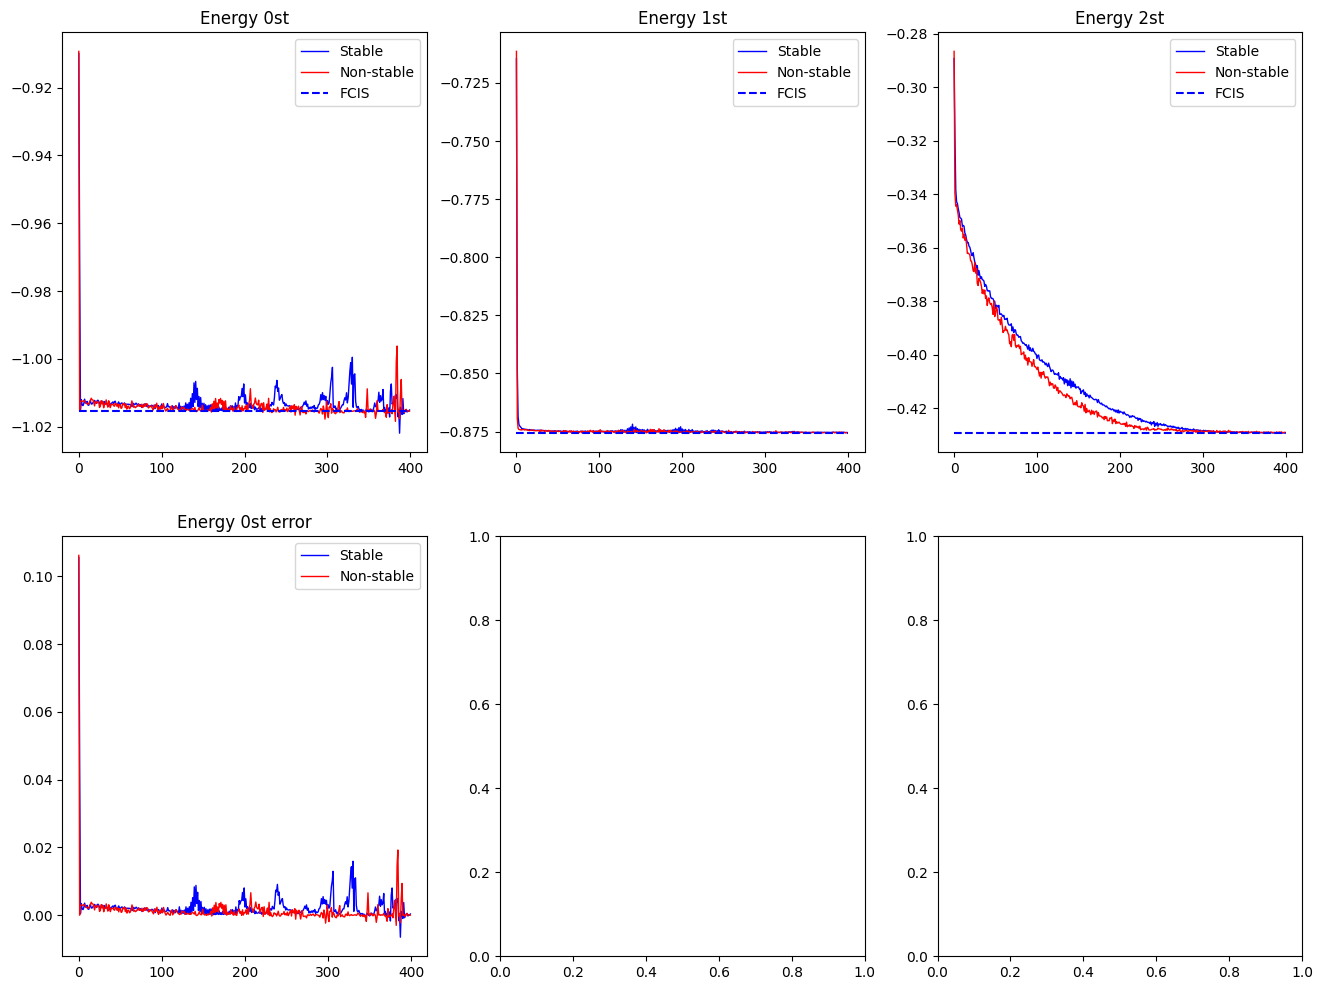

In [23]:
import matplotlib.pyplot as plt

fig,axs = plt.subplots(2,3,figsize=(16, 12))

axs[0,0].set_title('Energy 0st')
axs[0,0].plot(history_stable['energy_0st'], label='Stable',linewidth=1,color='blue')
axs[0,0].plot(history_nonstable['energy_0st'], label='Non-stable',linewidth=1,color='red')
axs[0,0].hlines(E_fcis[0], 0, len(history_stable['energy_0st']), label='FCIS', color='blue', linestyles='--')
axs[0,0].legend()

axs[0,1].set_title('Energy 1st')
axs[0,1].plot(history_stable['energy_1st'], label='Stable',linewidth=1,color='blue')
axs[0,1].plot(history_nonstable['energy_1st'], label='Non-stable',linewidth=1,color='red')
axs[0,1].hlines(E_fcis[1], 0, len(history_stable['energy_1st']), label='FCIS', color='blue', linestyles='--')
axs[0,1].legend()

axs[0,2].set_title('Energy 2st')
axs[0,2].plot(history_stable['energy_2st'], label='Stable',linewidth=1,color='blue')
axs[0,2].plot(history_nonstable['energy_2st'], label='Non-stable',linewidth=1,color='red')
axs[0,2].hlines(E_fcis[2], 0, len(history_stable['energy_2st']), label='FCIS', color='blue', linestyles='--')
axs[0,2].legend()



axs[1,0].set_title('Energy 0st error')
axs[1,0].plot(history_stable['energy_0st']-E_fcis[0], label='Stable',linewidth=1,color='blue')
axs[1,0].plot(history_nonstable['energy_0st']-E_fcis[0], label='Non-stable',linewidth=1,color='red')
#axs[1,0].hlines(E_fcis[2], 0, len(history_stable['energy_2st']), label='FCIS', color='blue', linestyles='--')
axs[1,0].legend()

